Image loaded successfully. Dimensions: 643x360
Original Image:


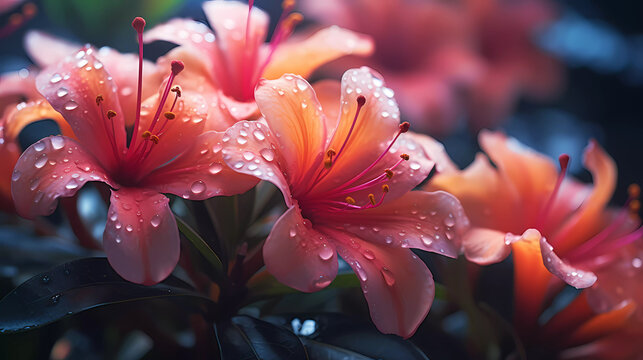

Cropped ROI:


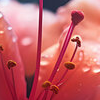

Image after pasting ROI:


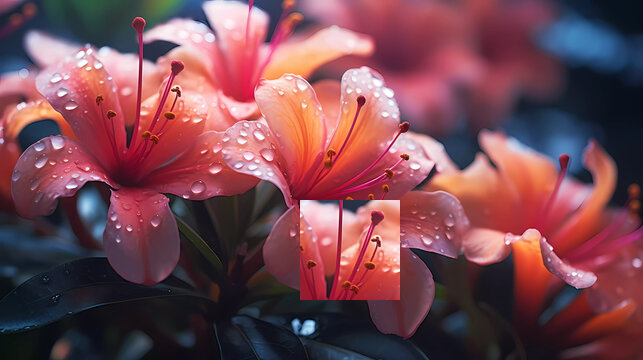

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # For displaying images in Colab

# Load the uploaded image
image = cv2.imread('/content/Flower.jpg')

if image is None:
    print("Error: Could not load image. Please check the path and ensure it's a valid image file.")
    # Optionally, exit or handle the error gracefully, e.g., create a dummy image as fallback
    # For this example, we'll stop execution if image not loaded.
else:
    height, width, _ = image.shape
    print(f"Image loaded successfully. Dimensions: {width}x{height}")

    # Display the original image
    print("Original Image:")
    cv2_imshow(image)

    # 1. Define the Region of Interest (ROI) for cropping
    # These are the coordinates (x_start, y_start, x_end, y_end)
    # These coordinates are based on the original dummy image, you might need to adjust them for 'Flower.jpg'
    roi_x_start = 100
    roi_y_start = 50
    roi_x_end = 200
    roi_y_end = 150

    # Ensure ROI is within image boundaries
    if roi_x_start < 0 or roi_y_start < 0 or roi_x_end > width or roi_y_end > height or \
       roi_x_end <= roi_x_start or roi_y_end <= roi_y_start:
        print("Error: ROI coordinates are out of image bounds or invalid. Please adjust them for the 'Flower.jpg' image.")
    else:
        # 2. Crop the ROI from the source image
        # In NumPy, slicing works as [y_start:y_end, x_start:x_end]
        cropped_roi = image[roi_y_start:roi_y_end, roi_x_start:roi_x_end]

        print("Cropped ROI:")
        cv2_imshow(cropped_roi)

        # 3. Copy the cropped ROI (already done by slicing, as it creates a new array)
        # If you need an explicit copy to ensure it's a separate memory block:
        # cropped_roi_copy = cropped_roi.copy()

        # 4. Paste the cropped ROI back into the original image at a new location
        # Define the new top-left corner coordinates for pasting
        paste_x_start = 300
        paste_y_start = 200

        # Calculate the end coordinates for pasting based on the cropped ROI's size
        roi_height, roi_width, _ = cropped_roi.shape
        paste_x_end = paste_x_start + roi_width
        paste_y_end = paste_y_start + roi_height

        # Check if the paste region is within image bounds
        if paste_x_end > width or paste_y_end > height:
            print("Error: Paste destination is out of image bounds. Please adjust paste coordinates.")
        else:
            # Paste the cropped ROI into the image
            image[paste_y_start:paste_y_end, paste_x_start:paste_x_end] = cropped_roi

            # Display the image with the pasted ROI
            print("Image after pasting ROI:")
            cv2_imshow(image)
